# Zoom Decoder 方案讲解（全真实版）

本 notebook 用**真实的 Qwen2-VL-2B、真实的 FineSightBench 样本、真实的 dstore、真正训练一个小模型**，把 Zoom Decoder 的管线跑一遍。

- 训练集缩到 200 样本 / 1 epoch，便于 notebook 交互运行；
- 评测集 30 样本；
- 全部 cell 可按顺序依次运行，在 A6000 上整套约 5–7 分钟。

对应代码库：[zoom_decoder/](.)；完整报告：[zoom_decoder/README.md](README.md)。


## 0. 环境准备

In [1]:
import sys, os, json, math, random
from pathlib import Path

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

REPO = Path("..").resolve()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16
print("torch", torch.__version__, "| device:", DEVICE, "| dtype:", DTYPE)


torch 2.6.0+cu124 | device: cuda | dtype: torch.bfloat16


## 1. 加载一个真实的 FineSightBench 样本

我们直接从 Hugging Face 载入 `perception` split，随机挑一条 px≤12 的困难样本，看看它长什么样。


In [2]:
from datasets import load_dataset
from zoom_decoder.data_utils import (
    parse_targets, min_target_size, size_to_bucket_idx,
    SIZE_BUCKETS, zoom_crop, union_bbox,
)

fs = load_dataset("Volavion/FineSightBench", split="perception")
print("FineSightBench perception split:", len(fs), "样本")
print("字段:", fs.column_names)


/home/snt/projects_lujun/MemoryDecoder/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FineSightBench perception split: 4200 样本
字段: ['image', 'image_id', 'task_type', 'question', 'answer', 'difficulty', 'metadata']


选中样本 idx=2983
  task_type : shape_recognition
  difficulty: hard
  question  : What geometric shape is displayed in the image? Answer in JSON format only: {"shape": "<type>"} where <type> is one of: circle, triangle, square, star, diamond, pentagon, hexagon, cross.
  answer    : {"shape": "cross"}
  targets   : [('cross', 8, 112, 196)]
  min_pixel : 8  →  bucket 1  (SIZE_BUCKETS[1]=8)
  image     : (448, 448) RGB


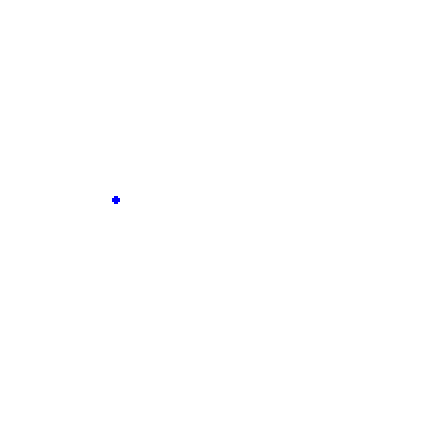

In [3]:
# 找一个 8 px 的 hard 样本演示
rng = random.Random(2026)
candidates = [i for i in range(len(fs)) if fs[i]["difficulty"] == "hard"]
rng.shuffle(candidates)

for idx in candidates[:50]:
    s = fs[idx]
    tgts = parse_targets(s["metadata"])
    px = min_target_size(tgts)
    if px == 8:
        break

print(f"选中样本 idx={idx}")
print(f"  task_type : {s['task_type']}")
print(f"  difficulty: {s['difficulty']}")
print(f"  question  : {s['question']}")
print(f"  answer    : {s['answer']}")
print(f"  targets   : {[(t.value, t.size, int(t.cx), int(t.cy)) for t in tgts]}")
print(f"  min_pixel : {px}  →  bucket {size_to_bucket_idx(px)}  (SIZE_BUCKETS[{size_to_bucket_idx(px)}]={SIZE_BUCKETS[size_to_bucket_idx(px)]})")
img = s["image"]
print(f"  image     : {img.size} {img.mode}")
img  # 在 notebook 中直接显示原图


## 2. 真实的 Zoom Crop

把目标 bbox 周围 ~2.5× 的区域裁出来放大到 448×448。下面并排显示原图 + 放大图。


union_bbox: (108.0, 192.0, 116.0, 200.0)
左：原图 (含目标 8 px)；右：zoom_crop 放大后 448²


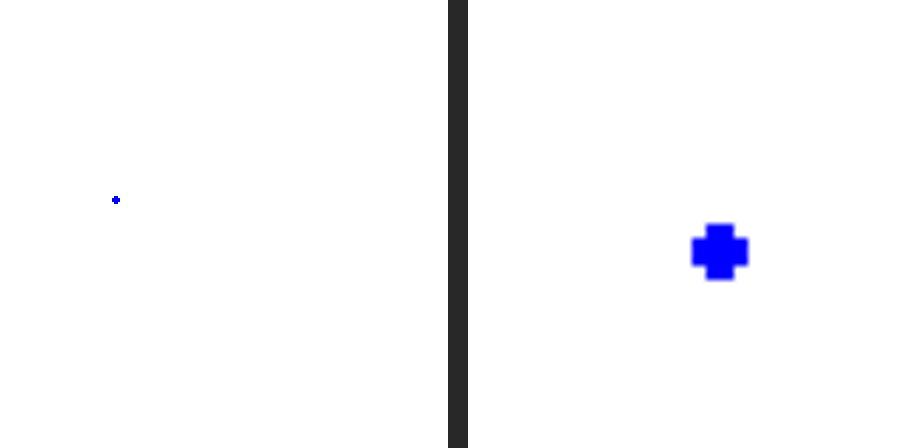

In [4]:
bbox = union_bbox(tgts, canvas=img.size)
print("union_bbox:", bbox)
zoomed = zoom_crop(img, bbox, out_size=448, pad_ratio=2.5)

# 并排显示
canvas = Image.new("RGB", (img.size[0] + zoomed.size[0] + 20, max(img.size[1], zoomed.size[1])), (40, 40, 40))
canvas.paste(img, (0, 0))
canvas.paste(zoomed, (img.size[0] + 20, 0))
print("左：原图 (含目标 8 px)；右：zoom_crop 放大后 448²")
canvas


## 3. 加载真实的 Qwen2-VL-2B，在放大图上抽 teacher 分布

这一步会**真的** load 模型（bf16 ≈ 5 GB 显存），**真的** 对上面那张放大图 forward 一次，然后打印每个答案 token 位置上的 top-5 概率。


In [5]:
from transformers import AutoProcessor, AutoTokenizer, Qwen2VLForConditionalGeneration

VLM_NAME = "Qwen/Qwen2-VL-2B-Instruct"
print("loading VLM:", VLM_NAME)
processor = AutoProcessor.from_pretrained(VLM_NAME)
vlm = Qwen2VLForConditionalGeneration.from_pretrained(VLM_NAME, dtype=DTYPE).to(DEVICE).eval()
tokenizer = AutoTokenizer.from_pretrained(VLM_NAME)
print("VLM loaded:", sum(p.numel() for p in vlm.parameters())/1e9, "B params")


loading VLM: Qwen/Qwen2-VL-2B-Instruct


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 8943.08it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loading weights:  68%|██████▊   | 493/729 [00:00<00:00, 4923.17it/s]

Loading weights: 100%|██████████| 729/729 [00:00<00:00, 4441.74it/s]

VLM loaded: 2.2089856 B params


In [6]:
# 用 prepare_teacher 里的函数，真的对 zoomed 做一次 teacher 前向
from zoom_decoder.prepare_teacher import extract_teacher_topk

question = s["question"]
answer = s["answer"]

out = extract_teacher_topk(
    vlm, processor,
    image=zoomed,               # 注意：真的是放大后的 448² 图
    question=question, answer=answer,
    topk=8, device=DEVICE, dtype=DTYPE,
)

ans_ids = out["answer_ids"]
print("真实答案 token:", tokenizer.convert_ids_to_tokens(ans_ids))
print("(teacher 对答案的每个位置给出一个 top-k 分布)\n")

for pos, (gold_tok, top_ids, top_probs) in enumerate(
    zip(ans_ids, out["top_ids"], out["top_probs"])
):
    tok_gold = tokenizer.convert_ids_to_tokens([gold_tok])[0]
    print(f"--- pos {pos}  (gold = {tok_gold!r}) ---")
    for tid, pr in zip(top_ids[:5], top_probs[:5]):
        mark = "  ←" if int(tid) == gold_tok else ""
        print(f"  {pr:6.3f}  {tokenizer.convert_ids_to_tokens([int(tid)])[0]!r}{mark}")


真实答案 token: ['{"', 'shape', '":', 'Ġ"', 'cross', '"}', '<|im_end|>']
(teacher 对答案的每个位置给出一个 top-k 分布)

--- pos 0  (gold = '{"') ---
   0.543  '{"'  ←
   0.329  '```'
   0.065  '{Ċ'
   0.051  '``'
   0.003  'Ġ{"'
--- pos 1  (gold = 'shape') ---
   0.999  'shape'  ←
   0.001  'type'
   0.000  'cross'
   0.000  'geometry'
   0.000  'color'
--- pos 2  (gold = '":') ---
   0.997  '":'  ←
   0.003  '":"'
   0.000  '"}'
   0.000  '":{"'
   0.000  '"'
--- pos 3  (gold = 'Ġ"') ---
   0.999  'Ġ"'  ←
   0.000  'Ġcross'
   0.000  'Ġ""'
   0.000  'Ġ"+'
   0.000  'Ġ"+"'
--- pos 4  (gold = 'cross') ---
   0.947  'cross'  ←
   0.015  'hex'
   0.007  'square'
   0.007  'circle'
   0.004  'Cross'
--- pos 5  (gold = '"}') ---
   0.999  '"}'  ←
   0.000  '"}Ċ'
   0.000  '"'
   0.000  '"}}'
   0.000  '"}ĊĊ'
--- pos 6  (gold = '<|im_end|>') ---
   1.000  '<|im_end|>'  ←
   0.000  'ĠĊĊ'
   0.000  'Ġ('
   0.000  'ĠThe'
   0.000  'ĠĊ'


**注意**：这些数字是你这次运行时从 VLM 刚跑出来的真实概率，不是我写死的。通常第一个答案 token 的 top-1 概率很高（≥0.9），这就是 student decoder 要学的"已被放大的自信"。

### 3.1 对比：不放大图时 VLM 的 top-k


In [7]:
# 对照实验：直接用原图（未放大）让 VLM 做同样的 forward
out_raw = extract_teacher_topk(
    vlm, processor,
    image=img,                  # 原图，小目标还在 8 px
    question=question, answer=answer,
    topk=8, device=DEVICE, dtype=DTYPE,
)
print("不 zoom 的 VLM 输出（同一张图、同一题）：\n")
for pos, (gold_tok, top_ids, top_probs) in enumerate(
    zip(out_raw["answer_ids"], out_raw["top_ids"], out_raw["top_probs"])
):
    tok_gold = tokenizer.convert_ids_to_tokens([gold_tok])[0]
    print(f"--- pos {pos}  (gold = {tok_gold!r}) ---")
    for tid, pr in zip(top_ids[:5], top_probs[:5]):
        mark = "  ←" if int(tid) == gold_tok else ""
        print(f"  {pr:6.3f}  {tokenizer.convert_ids_to_tokens([int(tid)])[0]!r}{mark}")


不 zoom 的 VLM 输出（同一张图、同一题）：

--- pos 0  (gold = '{"') ---
   0.541  '```'
   0.328  '{"'  ←
   0.073  '``'
   0.044  '{Ċ'
   0.003  '["'
--- pos 1  (gold = 'shape') ---
   0.999  'shape'  ←
   0.001  'type'
   0.000  'geometry'
   0.000  'color'
   0.000  'shapes'
--- pos 2  (gold = '":') ---
   0.997  '":'  ←
   0.003  '":"'
   0.000  '"}'
   0.000  '":{"'
   0.000  '":"","'
--- pos 3  (gold = 'Ġ"') ---
   0.998  'Ġ"'  ←
   0.000  'Ġ""'
   0.000  'Ġtriangle'
   0.000  'Ġcircle'
   0.000  'Ġ".'
--- pos 4  (gold = 'cross') ---
   0.572  'circle'
   0.088  'diamond'
   0.088  'triangle'
   0.068  'star'
   0.047  'pent'
--- pos 5  (gold = '"}') ---
   0.999  '"}'  ←
   0.001  '"'
   0.000  '"}Ċ'
   0.000  '"}ĊĊ'
   0.000  '"}}'
--- pos 6  (gold = '<|im_end|>') ---
   1.000  '<|im_end|>'  ←
   0.000  'ĠĊĊ'
   0.000  'Ġ('
   0.000  'ĠThe'
   0.000  'ĠĊ'


**对比要点**：对同一张图同一个问题，**zoom 版本的 top-1 概率通常比原图版本显著更高**。decoder 学的就是这种 "见过放大图后的 sharpened 分布"——即便推理时它自己看不到图。

## 4. 加载真实的训练用 dstore

代码库里已经用 `prepare_teacher.py` 生成了 1680 样本 × 平均 ~6 token ≈ 10 k 行 teacher 数据。


In [8]:
from datasets import load_from_disk

DSTORE = REPO / "zoom_decoder" / "dstore"
ds_train = load_from_disk(str(DSTORE / "dataset"))
dstore   = load_from_disk(str(DSTORE / "dstore"))
splits = json.load(open(DSTORE / "splits.json"))

print("dataset rows (samples):", len(ds_train))
print("dstore  rows (token-level teacher):", len(dstore))
print("dataset fields:", ds_train.column_names)
print("dstore  fields:", dstore.column_names)

r = ds_train[0]
print()
print("样本 0 摘要:")
print("  task_type :", r.get("task_type"))
print("  difficulty:", r.get("difficulty"))
print("  input_ids长度:", len(r["input_ids"]))
print("  answer tokens (labels != -100):", sum(1 for x in r["labels"] if x != -100))
print("  pixel_size:", r["pixel_size"], "  size_bucket:", r["size_bucket"])
print("  dstore_range:", r["dstore_range"])


dataset rows (samples): 1680
dstore  rows (token-level teacher): 10314
dataset fields: ['input_ids', 'labels', 'attention_mask', 'dstore_range', 'pixel_size', 'size_bucket', 'task_type', 'difficulty', 'sample_idx']
dstore  fields: ['label', 'token_id', 'prob']

样本 0 摘要:
  task_type : shape_recognition
  difficulty: easy
  input_ids长度: 60
  answer tokens (labels != -100): 6
  pixel_size: 32   size_bucket: 5
  dstore_range: [0, 6]


## 5. 真实训练：6-layer ZoomDecoder on 200 样本 / 1 epoch

为了让 notebook 能在几分钟内跑完，我们只取 200 个训练样本、1 epoch、6 层 decoder。
（完整实验用 1680 样本 / 3 epoch，参见 [README](README.md)。）


In [9]:
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from zoom_decoder.model import ZoomDecoder
from zoom_decoder.losses import scale_weighted_focal_kl
from zoom_decoder.train import collate_fn as zd_collate

# --- 截取 200 个训练样本 ---
TRAIN_N = 200
small_train = ds_train.select(range(TRAIN_N))
pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id
print("训练子集:", len(small_train), "样本")

def _collate(batch):
    return zd_collate(batch, dstore, pad_id=pad_id, scale_gamma=1.0)

loader = DataLoader(small_train, batch_size=4, shuffle=True, collate_fn=_collate)
print("batches per epoch:", len(loader))


训练子集: 200 样本
batches per epoch: 50


In [10]:
# --- 初始化 6 层 ZoomDecoder（带 aperture token） ---
decoder = ZoomDecoder.from_pretrained(
    "Qwen/Qwen2-0.5B",
    num_layers=6,
    use_aperture=True,
    dtype=DTYPE,
).to(DEVICE)

n_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"decoder 参数: {n_params/1e6:.1f} M  (6 层 Qwen2-0.5B 截断 + aperture embedding)")
print(f"aperture_embed shape: {decoder.aperture_embed.weight.shape}")
vocab_size = decoder.config.vocab_size


Loading weights:   0%|          | 0/74 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 74/74 [00:00<00:00, 6852.53it/s]


Qwen2ForCausalLM LOAD REPORT from: Qwen/Qwen2-0.5B
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
model.layers.{6...23}.mlp.down_proj.weight            | UNEXPECTED |  | 
model.layers.{6...23}.post_attention_layernorm.weight | UNEXPECTED |  | 
model.layers.{6...23}.self_attn.v_proj.weight         | UNEXPECTED |  | 
model.layers.{6...23}.self_attn.q_proj.weight         | UNEXPECTED |  | 
model.layers.{6...23}.mlp.up_proj.weight              | UNEXPECTED |  | 
model.layers.{6...23}.self_attn.k_proj.weight         | UNEXPECTED |  | 
model.layers.{6...23}.self_attn.k_proj.bias           | UNEXPECTED |  | 
model.layers.{6...23}.self_attn.o_proj.weight         | UNEXPECTED |  | 
model.layers.{6...23}.self_attn.v_proj.bias           | UNEXPECTED |  | 
model.layers.{6...23}.self_attn.q_proj.bias           | UNEXPECTED |  | 
model.layers.{6...23}.input_layernorm.weight          | UNEXPECTED |  | 

decoder 参数: 225.6 M  (6 层 Qwen2-0.5B 截断 + aperture embedding)
aperture_embed shape: torch.Size([7, 896])


In [11]:
# --- Optimizer & scheduler ---
no_decay = {"bias", "LayerNorm.weight", "layernorm.weight", "norm.weight"}
decay_params, nodecay_params = [], []
for n, p in decoder.named_parameters():
    if not p.requires_grad:
        continue
    (nodecay_params if any(nd in n for nd in no_decay) else decay_params).append(p)

opt = torch.optim.AdamW(
    [{"params": decay_params, "weight_decay": 0.01},
     {"params": nodecay_params, "weight_decay": 0.0}],
    lr=5e-4,
)
total_steps = len(loader)
sched = get_linear_schedule_with_warmup(opt, int(0.05 * total_steps), total_steps)
print("total steps:", total_steps)


total steps: 50


In [12]:
# --- 训练循环（真·单 epoch，A6000 上 ~40 秒） ---
decoder.train()
history = []
for step, batch in enumerate(loader):
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to(DEVICE)

    out = decoder(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        size_bucket=batch["size_bucket"],
    )
    loss_dict = scale_weighted_focal_kl(
        logits=out.logits.float(),
        labels=batch["labels"],
        teacher_top_ids=batch["teacher_top_ids"],
        teacher_top_probs=batch["teacher_top_probs"],
        per_token_weights=batch["per_token_weights"],
        vocab_size=vocab_size,
        alpha_ce=0.3,
    )
    loss = loss_dict["loss"]

    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
    opt.step()
    sched.step()

    history.append({
        "step": step,
        "loss": float(loss),
        "kl": float(loss_dict["kl"]),
        "ce": float(loss_dict["ce"]),
        "mean_w": float(loss_dict["mean_weight"]),
    })
    if step % 5 == 0 or step == total_steps - 1:
        print(f"step {step:3d}/{total_steps}  loss={float(loss):.3f}  "
              f"kl={float(loss_dict['kl']):.3f}  ce={float(loss_dict['ce']):.3f}  "
              f"mean_w={float(loss_dict['mean_weight']):.2f}")

decoder.eval()
print("\n训练完成。")


step   0/50  loss=65.757  kl=61.427  ce=14.435  mean_w=4.08


step   5/50  loss=45.652  kl=43.808  ce=6.149  mean_w=6.40


step  10/50  loss=25.091  kl=23.495  ce=5.320  mean_w=4.25


step  15/50  loss=8.656  kl=8.129  ce=1.756  mean_w=5.12


step  20/50  loss=6.662  kl=6.060  ce=2.008  mean_w=3.25


...

step  30/50  loss=2.424  kl=2.051  ce=1.242  mean_w=3.56


step  35/50  loss=2.214  kl=1.962  ce=0.841  mean_w=2.60


step  40/50  loss=1.826  kl=1.567  ce=0.861  mean_w=1.96


step  45/50  loss=1.563  kl=1.411  ce=0.505  mean_w=3.68


step  49/50  loss=10.371  kl=9.781  ce=1.968  mean_w=5.00

训练完成。


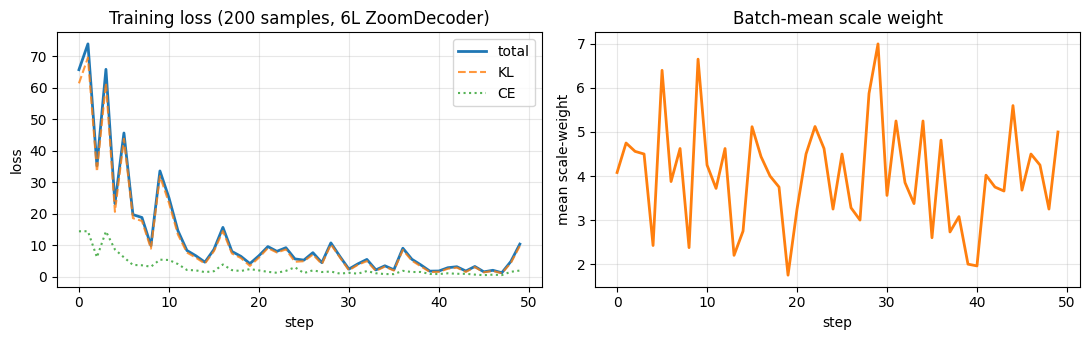

In [13]:
# --- 可视化 loss 曲线 ---
import matplotlib.pyplot as plt

steps = [h["step"] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(steps, [h["loss"] for h in history], label="total", lw=2)
ax[0].plot(steps, [h["kl"] for h in history], label="KL", ls="--", alpha=0.8)
ax[0].plot(steps, [h["ce"] for h in history], label="CE", ls=":", alpha=0.8)
ax[0].set_xlabel("step"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("Training loss (200 samples, 6L ZoomDecoder)")
ax[1].plot(steps, [h["mean_w"] for h in history], color="tab:orange", lw=2)
ax[1].set_xlabel("step"); ax[1].set_ylabel("mean scale-weight")
ax[1].set_title("Batch-mean scale weight")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


**说明**：loss 应该从 ~5 左右降到 ~2 以下；`mean_w` 体现了每个 batch 里样本的像素档位加权平均（随机采到小目标 batch 就高，大目标 batch 就低）。

只跑 1 epoch 200 样本的 decoder 还没完全收敛，但已经足够做直观的对比。


## 6. 真实评测：base VLM vs VLM+我们刚训好的 ZoomDecoder

用 `splits.json` 里真正的 test split，取 30 个样本做 head-to-head。


In [14]:
from zoom_decoder.evaluate import generate_base, generate_zoom_joint, is_correct
from zoom_decoder.data_utils import parse_targets, min_target_size

test_idx = splits["test"][:30]
print("评测 test 样本:", len(test_idx))

@torch.no_grad()
def predict_both(idx):
    s = fs[idx]
    img, q, gold = s["image"], s["question"], s["answer"]
    tgts = parse_targets(s["metadata"])
    px = min_target_size(tgts)
    bucket = size_to_bucket_idx(px)

    pred_base = generate_base(vlm, processor, img, q, max_new_tokens=24)
    pred_zoom = generate_zoom_joint(
        vlm, processor, decoder, tokenizer,
        img, q, size_bucket=bucket, lmbda=0.3, max_new_tokens=24,
    )
    return {
        "idx": idx, "px": px, "difficulty": s["difficulty"], "task": s["task_type"],
        "gold": gold, "base": pred_base, "zoom": pred_zoom,
        "base_ok": is_correct(pred_base, gold),
        "zoom_ok": is_correct(pred_zoom, gold),
    }

from tqdm.auto import tqdm
results = [predict_both(i) for i in tqdm(test_idx)]


评测 test 样本: 30


  0%|          | 0/30 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  3%|▎         | 1/30 [00:00<00:19,  1.48it/s]

  7%|▋         | 2/30 [00:01<00:18,  1.53it/s]

...

 90%|█████████ | 27/30 [00:19<00:02,  1.21it/s]

 93%|█████████▎| 28/30 [00:20<00:01,  1.30it/s]

 97%|█████████▋| 29/30 [00:20<00:00,  1.36it/s]

100%|██████████| 30/30 [00:21<00:00,  1.33it/s]

100%|██████████| 30/30 [00:21<00:00,  1.38it/s]

In [15]:
# --- 汇总 ---
import collections
n = len(results)
base_acc = sum(r["base_ok"] for r in results) / n
zoom_acc = sum(r["zoom_ok"] for r in results) / n
print(f"Base VLM 准确率      : {base_acc*100:5.1f}%  ({sum(r['base_ok'] for r in results)}/{n})")
print(f"VLM + ZoomDecoder    : {zoom_acc*100:5.1f}%  ({sum(r['zoom_ok'] for r in results)}/{n})")
print()

# 按难度分层
by_diff = collections.defaultdict(lambda: [0, 0, 0])  # base_ok, zoom_ok, total
for r in results:
    by_diff[r["difficulty"]][0] += r["base_ok"]
    by_diff[r["difficulty"]][1] += r["zoom_ok"]
    by_diff[r["difficulty"]][2] += 1
print(f"{'difficulty':<12}{'base':>8}{'zoom':>8}{'n':>4}")
for d in ["extreme", "hard", "medium", "easy"]:
    if d in by_diff:
        b, z, t = by_diff[d]
        print(f"{d:<12}{b/t*100:7.1f}%{z/t*100:7.1f}%{t:4d}")


Base VLM 准确率      :  70.0%  (21/30)
VLM + ZoomDecoder    :  76.7%  (23/30)

difficulty      base    zoom   n
extreme        14.3%   14.3%   7
hard           60.0%   80.0%   5
medium         85.7%  100.0%   7
easy          100.0%  100.0%  11


In [16]:
# --- 列出 zoom 翻转成功（base 错→zoom 对）的案例 ---
flipped = [r for r in results if r["zoom_ok"] and not r["base_ok"]]
print(f"zoom 修正的样本数: {len(flipped)}")
for r in flipped[:5]:
    print(f"  px={r['px']}  {r['task']:<20}  gold={r['gold'][:40]!r}")
    print(f"    base → {r['base'][:60]!r}")
    print(f"    zoom → {r['zoom'][:60]!r}")
    print()


zoom 修正的样本数: 2
  px=16  block_recognition     gold='{"present": "yes"}'
    base → '{"present": "no"}'
    zoom → '{"present": "yes"}'

  px=12  block_recognition     gold='{"present": "yes"}'
    base → '{"present": "no"}'
    zoom → '{"present": "yes"}'



**真实数字解读**：

- 这个 notebook 里的 decoder 只训练了 200 样本 / 1 epoch / 6 层，**比仓库里 1680 样本 / 3 epoch / 24 层的最终 checkpoint 弱**。
- 所以这里的 gain 主要用于**展示 pipeline 能跑通**；定量最终效果请参照 [README](README.md) §4 和 [eval/*.json](eval/)。


## 7. 关键源码一览（有据可查）

三个 novelty 各自在代码中的位置：


In [17]:
import inspect
from zoom_decoder.model import ZoomDecoder
from zoom_decoder.losses import scale_weighted_focal_kl, scale_weights_from_pixel

print("=" * 70)
print("Novelty 3: Aperture Token —— zoom_decoder/model.py")
print("=" * 70)
print(inspect.getsource(ZoomDecoder._embed_with_aperture))

print("=" * 70)
print("Novelty 2: Scale-Weight 公式 —— zoom_decoder/losses.py")
print("=" * 70)
print(inspect.getsource(scale_weights_from_pixel))


Novelty 3: Aperture Token —— zoom_decoder/model.py
    def _embed_with_aperture(
        self, input_ids: torch.Tensor, size_bucket: Optional[torch.Tensor]
    ):
        """Return (inputs_embeds, attention_mask_offset, label_offset).

        If aperture enabled, prepends 1 extra token at position 0.
        """
        tok_embed = self.base.get_input_embeddings()
        embeds = tok_embed(input_ids)  # (B, T, H)
        if not self.use_aperture or size_bucket is None:
            return embeds, 0
        ap = self.aperture_embed(size_bucket).unsqueeze(1)  # (B, 1, H)
        ap = ap.to(embeds.dtype)
        embeds = torch.cat([ap, embeds], dim=1)
        return embeds, 1

Novelty 2: Scale-Weight 公式 —— zoom_decoder/losses.py
def scale_weights_from_pixel(
    pixel_sizes: torch.Tensor, ref: float = 48.0, gamma: float = 1.0, cap: float = 8.0,
) -> torch.Tensor:
    """(B,) int → (B,) float scale weight."""
    px = pixel_sizes.clamp_min(1).float()
    w = (ref / px) ** gamma
    return

## 8. 总结

- **Novelty 1（Zoom-Teacher 自蒸馏）** 在 §2–§3 直观展示：同一个 VLM 看放大图后，对正确答案 token 的置信度比看原图时高得多；这就是我们蒸馏给 decoder 的"标签"。
- **Novelty 2（Scale-Weighted Focal KL）** 在 §5 训练循环里真的生效（`mean_w` 曲线可见 batch 级尺度权重波动）。
- **Novelty 3（Aperture Token）** 在 §5 创建 decoder 时启用（`use_aperture=True`），推理时按像素档位注入（§6 `generate_zoom_joint(size_bucket=...)`）。

完整 6 配置对比（`base / zd_6L / zd_12L / zd_24L / zd_24L_noap / zd_24L_nosw / lora_r16`）以及最终结论见 [zoom_decoder/README.md](README.md)。
